In [ ]:
import pandas as pd

# Загрузка данных
developers_mkd_df = pd.read_csv('mkd_developer_activity.csv')
appart_mkd_df = pd.read_csv('mkd_appartments_monthly.csv')
popular_igs_charact_df = pd.read_csv('igs_house_characteristics_popularity.csv')

# Первые строки
print(developers_mkd_df.head())
print(developers_mkd_df.info())
print(developers_mkd_df.isnull().sum())

print(appart_mkd_df.head())
print(appart_mkd_df.info())
print(appart_mkd_df.isnull().sum())

print(popular_igs_charact_df.head())
print(popular_igs_charact_df.info())
print(popular_igs_charact_df.isnull().sum())

   developer_id      developer_name  developer_inn  developer_ogrn  \
0          7364        СЗ-1 ЮСИ-ДОН     6163148597   1166196086891   
1         37320          СЗ ОКТЯБРЬ     9403032756   1259400001992   
2           154            БРУСНИКА     6671382990   1116671018958   
3         18490  СЗ ГРАДСТРОЙПРОЕКТ     2311311443   1202300058586   
4         15042      СЗ СЭТЛ ЭСТЕЙТ     7810733993   1187847194490   

   active_projects  total_construction_volume  living_construction_volume  \
0              147                 2160077.90                  1268390.00   
1               14                 1824866.68                    85300.00   
2               47                 1460717.61                   842578.13   
3               74                 1095049.35                   511021.83   
4               23                  995726.41                   543516.30   

   avg_project_floors  regions_count  
0               11.67              1  
1               14.36              1  

Правила для датасетов


In [ ]:
# Словарь с правилами для каждого датасета
validation_rules = {
    'developers_mkd_df': {
        'required_columns': ['developer_id', 'active_projects', 'total_construction_volume'],
        'unique_columns': ['developer_id'],
        'non_negative_columns': ['active_projects', 'total_construction_volume'],
        'max_null_fraction': 0.2  # максимум 20% пропусков
    },
    'appart_mkd_df': {
        'required_columns': ['month_dt', 'total_area', 'living_area'],
        'positive_columns': ['total_area', 'living_area'],
        'date_columns': ['month_dt'],
        'max_null_fraction': 0.1
    },
    'popular_igs_charact_df': {
        'required_columns': ['wall_material', 'avg_house_area', 'avg_cost', 'avg_construction_period'],
        'positive_columns': ['avg_house_area', 'avg_cost', 'avg_construction_period'],
        'max_null_fraction': 0.15
    }
}

Функция проверки по значениям


In [ ]:
import pandas as pd
from datetime import datetime

def validate_dataset(df, dataset_name, rules):
    """
    Универсальная функция проверки датасета
    """
    print(f"\n{'='*50}")
    print(f"ПРОВЕРКА ДАТАСЕТА: {dataset_name}")
    print(f"{'='*50}")

    errors = []
    warnings = []

    # 1. Проверка наличия обязательных колонок
    if 'required_columns' in rules:
        missing_cols = [col for col in rules['required_columns'] if col not in df.columns]
        if missing_cols:
            errors.append(f"❌ Отсутствуют обязательные колонки: {missing_cols}")
        else:
            print(f"✅ Все обязательные колонки присутствуют")

    # 2. Проверка уникальности колонок
    if 'unique_columns' in rules:
        for col in rules['unique_columns']:
            if col in df.columns:
                duplicates = df[col].duplicated().sum()
                if duplicates > 0:
                    errors.append(f"❌ Колонка '{col}' содержит {duplicates} дубликатов")
                else:
                    print(f"✅ Колонка '{col}' уникальна")

    # 3. Проверка неотрицательных значений
    if 'non_negative_columns' in rules:
        for col in rules['non_negative_columns']:
            if col in df.columns:
                negative_count = (df[col] < 0).sum()
                if negative_count > 0:
                    errors.append(f"❌ Колонка '{col}' содержит {negative_count} отрицательных значений")
                else:
                    print(f"✅ Колонка '{col}' не содержит отрицательных значений")

    # 4. Проверка положительных значений (>0)
    if 'positive_columns' in rules:
        for col in rules['positive_columns']:
            if col in df.columns:
                zero_or_negative = (df[col] <= 0).sum()
                if zero_or_negative > 0:
                    errors.append(f"❌ Колонка '{col}' содержит {zero_or_negative} нулевых или отрицательных значений")
                else:
                    print(f"✅ Колонка '{col}' содержит только положительные значения")

    # 5. Проверка пропусков
    if 'max_null_fraction' in rules:
        null_fraction = df.isnull().sum().sum() / (df.shape[0] * df.shape[1])
        if null_fraction > rules['max_null_fraction']:
            errors.append(f"❌ Доля пропусков {null_fraction:.2%} превышает допустимую {rules['max_null_fraction']:.0%}")
        else:
            print(f"✅ Доля пропусков {null_fraction:.2%} в пределах нормы")

    # 6. Проверка формата дат
    if 'date_columns' in rules:
        for col in rules['date_columns']:
            if col in df.columns:
                try:
                    pd.to_datetime(df[col])
                    print(f"✅ Колонка '{col}' имеет корректный формат даты")
                except:
                    errors.append(f"❌ Колонка '{col}' НЕ является корректной датой")

    # 7. Дополнительные проверки для конкретных колонок
    if dataset_name == 'developers_mkd_df':
        if 'active_projects' in df.columns:
            max_val = df['active_projects'].max()
            if max_val > 1000:
                warnings.append(f"⚠️ Максимальное значение active_projects = {max_val}, возможно, требует проверки")

    if dataset_name == 'popular_igs_charact_df':
        if 'wall_material' in df.columns:
            unique_materials = df['wall_material'].nunique()
            print(f"ℹ️ Количество уникальных материалов стен: {unique_materials}")

    # ИТОГ
    print(f"\n{'─'*50}")
    if errors:
        print(f"❌ РЕЗУЛЬТАТ: ДАТАСЕТ НЕ ПРОШЁЛ ПРОВЕРКУ")
        print("Ошибки:")
        for err in errors:
            print(f"  {err}")
    else:
        print(f"✅ РЕЗУЛЬТАТ: ДАТАСЕТ ПРОШЁЛ ПРОВЕРКУ")

    if warnings:
        print("\nПредупреждения:")
        for warn in warnings:
            print(f"  {warn}")

    print(f"{'='*50}\n")

    return len(errors) == 0, errors, warnings

Проверка

In [ ]:
# Создаём словарь с датафреймами
datasets = {
    'developers_mkd_df': developers_mkd_df,
    'appart_mkd_df': appart_mkd_df,
    'popular_igs_charact_df': popular_igs_charact_df
}

# Запускаем проверку для каждого
all_passed = True
for name, df in datasets.items():
    passed, errors, warnings = validate_dataset(df, name, validation_rules.get(name, {}))
    if not passed:
        all_passed = False

# Финальный вывод
print("\n" + "="*50)
print("ИТОГОВЫЙ ВЕРДИКТ ПО ВСЕМ ДАТАСЕТАМ")
print("="*50)
if all_passed:
    print("✅ Все датасеты прошли проверку. Данные готовы для построения модели.")
else:
    print("❌ Некоторые датасеты не прошли проверку. Требуется очистка данных.")


ПРОВЕРКА ДАТАСЕТА: developers_mkd_df
✅ Все обязательные колонки присутствуют
✅ Колонка 'developer_id' уникальна
✅ Колонка 'active_projects' не содержит отрицательных значений
✅ Колонка 'total_construction_volume' не содержит отрицательных значений
✅ Доля пропусков 0.00% в пределах нормы

──────────────────────────────────────────────────
✅ РЕЗУЛЬТАТ: ДАТАСЕТ ПРОШЁЛ ПРОВЕРКУ


ПРОВЕРКА ДАТАСЕТА: appart_mkd_df
✅ Все обязательные колонки присутствуют
✅ Колонка 'total_area' содержит только положительные значения
✅ Колонка 'living_area' содержит только положительные значения
✅ Доля пропусков 0.00% в пределах нормы
✅ Колонка 'month_dt' имеет корректный формат даты

──────────────────────────────────────────────────
✅ РЕЗУЛЬТАТ: ДАТАСЕТ ПРОШЁЛ ПРОВЕРКУ


ПРОВЕРКА ДАТАСЕТА: popular_igs_charact_df
✅ Все обязательные колонки присутствуют
✅ Колонка 'avg_house_area' содержит только положительные значения
✅ Колонка 'avg_cost' содержит только положительные значения
ℹ️ Количество уникальных материал


📊 ОТЧЁТ ПО ДАТАСЕТУ: developers_mkd_df

📌 ОБЩАЯ ИНФОРМАЦИЯ:
   • Количество строк: 4,631
   • Количество колонок: 9
   • Количество дубликатов строк: 0

✅ Пропуски отсутствуют

📌 СТАТИСТИКА ПО ЧИСЛОВЫМ КОЛОНКАМ:
       developer_id  developer_inn  developer_ogrn  active_projects  \
count       4631.00   4.631000e+03    4.631000e+03          4631.00   
mean       15763.31   4.841237e+09    1.211728e+12             2.83   
std         8670.29   2.648126e+09    3.584596e+11             6.16   
min            7.00   1.000005e+08    1.020101e+12             1.00   
25%        10708.50   2.536268e+09    1.145476e+12             1.00   
50%        16238.00   5.030099e+09    1.204700e+12             1.00   
75%        19323.00   7.203475e+09    1.231450e+12             3.00   
max        41727.00   9.731123e+09    5.187746e+12           195.00   

       total_construction_volume  living_construction_volume  \
count                    4631.00                     4631.00   
mean               

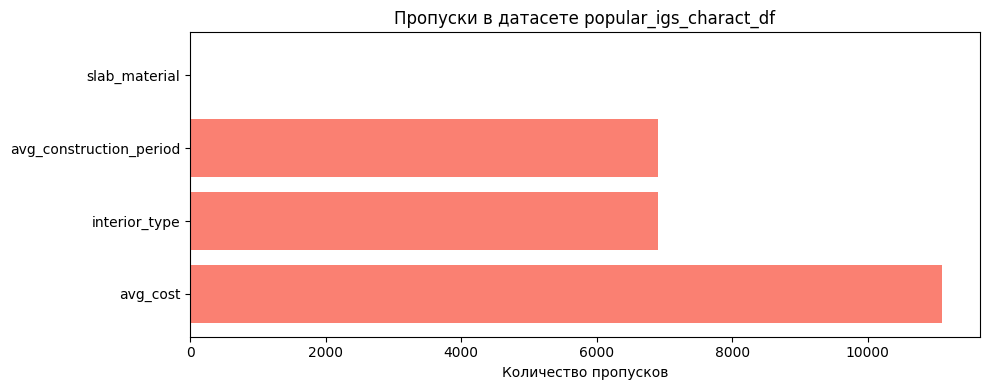


📌 СТАТИСТИКА ПО ЧИСЛОВЫМ КОЛОНКАМ:
       usage_count  avg_house_area     avg_cost  avg_construction_period  \
count     11602.00        11602.00       501.00                  4699.00   
mean          4.06          120.56   6907996.93                     7.53   
std          15.71           48.44   3920700.47                     4.05   
min           1.00           20.30         1.00                     0.00   
25%           1.00           90.05   4650000.00                     5.00   
50%           1.00          111.08   6130000.00                     7.00   
75%           2.00          139.00   8046632.00                     9.00   
max         630.00          548.00  34520426.00                   119.00   

       unique_contractors  
count            11602.00  
mean                 0.83  
std                  2.62  
min                  0.00  
25%                  0.00  
50%                  0.00  
75%                  1.00  
max                 65.00  
   ⚠️ avg_construction_peri

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_data_report(df, dataset_name):
    """
    Генерирует подробный отчёт по датасету с визуализациями
    """
    print(f"\n{'='*60}")
    print(f"📊 ОТЧЁТ ПО ДАТАСЕТУ: {dataset_name}")
    print(f"{'='*60}")

    # 1. Общая информация
    print(f"\n📌 ОБЩАЯ ИНФОРМАЦИЯ:")
    print(f"   • Количество строк: {df.shape[0]:,}")
    print(f"   • Количество колонок: {df.shape[1]}")
    print(f"   • Количество дубликатов строк: {df.duplicated().sum():,}")

    # 2. Анализ пропусков
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Колонка': missing.index,
                               'Пропуски': missing.values,
                               'Доля %': missing_pct.values})
    missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values('Пропуски', ascending=False)

    if not missing_df.empty:
        print(f"\n📌 ПРОПУСКИ В ДАННЫХ:")
        print(missing_df.to_string(index=False))

        # Визуализация пропусков
        plt.figure(figsize=(10, 4))
        plt.barh(missing_df['Колонка'], missing_df['Пропуски'], color='salmon')
        plt.xlabel('Количество пропусков')
        plt.title(f'Пропуски в датасете {dataset_name}')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n✅ Пропуски отсутствуют")

    # 3. Анализ числовых колонок
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\n📌 СТАТИСТИКА ПО ЧИСЛОВЫМ КОЛОНКАМ:")
        print(df[numeric_cols].describe().round(2))

        # Проверка на отрицательные/нулевые значения
        for col in numeric_cols:
            negative = (df[col] < 0).sum()
            zero = (df[col] == 0).sum()
            if negative > 0:
                print(f"   ⚠️ {col}: {negative} отрицательных значений")
            if zero > 0 and col not in ['developer_id', 'active_projects']:
                print(f"   ⚠️ {col}: {zero} нулевых значений")

    # 4. Анализ категориальных колонок
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"\n📌 КАТЕГОРИАЛЬНЫЕ КОЛОНКИ:")
        for col in categorical_cols:
            unique_count = df[col].nunique()
            top_values = df[col].value_counts().head(3)
            print(f"   • {col}: {unique_count} уникальных значений")
            print(f"     Топ-3: {dict(top_values)}")

    # 5. Вывод о качестве данных
    print(f"\n📌 ВЕРДИКТ ПО ДАТАСЕТУ:")
    issues = []

    # Проверка на пропуски > 10%
    if (missing_pct > 10).any():
        high_missing = missing_pct[missing_pct > 10].index.tolist()
        issues.append(f"⚠️ Колонки с >10% пропусков: {high_missing}")

    # Проверка на дубликаты
    if df.duplicated().sum() > 0:
        issues.append(f"⚠️ Найдено {df.duplicated().sum()} дубликатов строк")

    # Проверка на отрицательные значения
    for col in numeric_cols:
        if (df[col] < 0).any():
            issues.append(f"⚠️ Колонка '{col}' содержит отрицательные значения")

    if issues:
        for issue in issues:
            print(f"   {issue}")
        print(f"\n   🔧 Рекомендации:")
        print(f"   • Пропуски >10%: заполнить медианой (числовые) или 'unknown' (категориальные)")
        print(f"   • Дубликаты: удалить командой df.drop_duplicates()")
        print(f"   • Отрицательные значения: заменить на 0 или удалить строки")
    else:
        print(f"   ✅ Данные чистые, можно использовать для моделирования")

# Запуск отчёта для каждого датасета
for name, df in datasets.items():
    generate_data_report(df, name)

In [ ]:
# Детальный разбор проблемного датасета
print("\n" + "="*60)
print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ПРОБЛЕМ: popular_igs_charact_df")
print("="*60)

# Проверка строки с нулевым сроком строительства
problem_rows = popular_igs_charact_df[popular_igs_charact_df['avg_construction_period'] <= 0]
print(f"\n📌 Строка с avg_construction_period <= 0:")
print(problem_rows.to_string())

# Анализ пропусков по колонкам
missing_detail = popular_igs_charact_df.isnull().sum()
missing_detail = missing_detail[missing_detail > 0].sort_values(ascending=False)
print(f"\n📌 Распределение пропусков по колонкам:")
for col, count in missing_detail.items():
    pct = count / len(popular_igs_charact_df) * 100
    print(f"   • {col}: {count} пропусков ({pct:.1f}%)")


🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ПРОБЛЕМ: popular_igs_charact_df

📌 Строка с avg_construction_period <= 0:
              wall_material foundation_type    roof_type architectural_style interior_type interior_wall_material facade_material slab_material  is_green_house  usage_count  avg_house_area  avg_cost  avg_construction_period  unique_contractors
11515  Деревянные каркасные         Свайный  Односкатная          Минимализм      Черновая             Деревянные         Планкен    Деревянные           False            1           162.0       1.0                      0.0                   0

📌 Распределение пропусков по колонкам:
   • avg_cost: 11101 пропусков (95.7%)
   • interior_type: 6909 пропусков (59.6%)
   • avg_construction_period: 6903 пропусков (59.5%)
   • slab_material: 1 пропусков (0.0%)


In [ ]:
# Сводная информация для ДЗ
summary_data = []

for name, df in datasets.items():
    summary_data.append({
        'Датасет': name,
        'Строки': df.shape[0],
        'Колонки': df.shape[1],
        'Пропуски %': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
        'Дубликаты': df.duplicated().sum(),
        'Статус': '✅ Готов' if name != 'popular_igs_charact_df' else '⚠️ Требует очистки'
    })

summary_df = pd.DataFrame(summary_data)
print("\n📊 СВОДНАЯ ТАБЛИЦА ПО ВСЕМ ДАТАСЕТАМ")
print(summary_df.to_string(index=False))


📊 СВОДНАЯ ТАБЛИЦА ПО ВСЕМ ДАТАСЕТАМ
               Датасет  Строки  Колонки  Пропуски %  Дубликаты             Статус
     developers_mkd_df    4631        9        0.00          0            ✅ Готов
         appart_mkd_df    5259       10        0.00          0            ✅ Готов
popular_igs_charact_df   11602       14       15.34          0 ⚠️ Требует очистки


## 1. Источники и состав данных

### Источники
Все данные получены с платформы ДОМ.РФ (официальный источник Минстроя РФ).

### Используемые датасеты

| Название | Строки | Колонки | Описание |
| :--- | :--- | :--- | :--- |
| `mkd_developer_activity.csv` | {developers_mkd_df.shape[0]} | {developers_mkd_df.shape[1]} | Активность застройщиков |
| `mkd_appartments_monthly.csv` | {appart_mkd_df.shape[0]} | {appart_mkd_df.shape[1]} | Квартирография (помесячно) |
| `igs_house_characteristics_popularity.csv` | {popular_igs_charact_df.shape[0]} | {popular_igs_charact_df.shape[1]} | Характеристики домов |

### Ключевые колонки для моделирования

| Датасет | Колонка | Тип | Важность |
| :--- | :--- | :--- | :--- |
| Застройщики | `active_projects` | int | Высокая (опыт девелопера) |
| Застройщики | `total_construction_volume` | float | Средняя |
| Квартирография | `total_area` | float | Высокая (объём рынка) |
| Характеристики | `wall_material` | string | Средняя |
| Характеристики | `avg_cost` | float | Целевая переменная |

## 2. Оценка качества разметки

### Выявленные проблемы
1. **Пропуски:** 15.34% в датасете характеристик домов (превышает порог 15%).
2. **Аномалии:** 1 строка с нулевым значением `avg_construction_period`.
3. **Дубликаты:** не обнаружены.

### Предложения по повышению качества
1. Удалить строку с `avg_construction_period <= 0`.
2. Заполнить пропуски в категориальных колонках значением `'unknown'`.
3. Заполнить пропуски в числовых колонках медианой.
4. После очистки данные пригодны для моделирования.

In [ ]:
from sklearn.model_selection import train_test_split

print("\n" + "="*50)
print("ФОРМИРОВАНИЕ ВЫБОРКИ ДЛЯ МОДЕЛИРОВАНИЯ")
print("="*50)

# Пример на датасете характеристик домов (есть целевая переменная)
if 'avg_cost' in popular_igs_charact_df.columns:
    # Удаляем строки с пропусками в целевой переменной
    df_model = popular_igs_charact_df.dropna(subset=['avg_cost']).copy()

    # Признаки и целевая переменная
    feature_cols = ['avg_house_area', 'avg_construction_period', 'wall_material']
    # Берём только те колонки, которые есть в датасете
    feature_cols = [col for col in feature_cols if col in df_model.columns]

    X = df_model[feature_cols]
    y = df_model['avg_cost']

    # Разделение на train (70%), val (15%), test (15%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    print(f"Train: {len(X_train)} строк")
    print(f"Val: {len(X_val)} строк")
    print(f"Test: {len(X_test)} строк")
else:
    print("Целевая переменная 'avg_cost' не найдена")


ФОРМИРОВАНИЕ ВЫБОРКИ ДЛЯ МОДЕЛИРОВАНИЯ
Train: 350 строк
Val: 75 строк
Test: 76 строк


## 3. Стратегия валидации

Для оценки качества модели будет использоваться:

1. **Кросс-валидация (K-Fold, k=5)** на тренировочной выборке для подбора гиперпараметров.
2. **Отложенная валидация (hold-out)** на тестовой выборке для финальной оценки.
3. **Метрики:** MAE, RMSE, R².

Так как данные не являются временным рядом, временная кросс-валидация не требуется.